# **AVALIAÇÃO DO MODELO DESENVOLVIDO**
### *Case: Risco de Crédito (Home Credit Default Risk)*

Este notebook avalia **exclusivamente o modelo escolhido**

- A **seleção/comparação** entre algoritmos (Logística, Floresta, XGBoost, LightGBM), a busca de
  hiperparâmetros e o controle de overfitting estão em **`validacao_modelos.ipynb`** (etapa de desenvolvimento).
- Aqui reproduzimos **a mesma lógica do `train.py`** (categóricas **nativas** do LightGBM, mesmo split
  estratificado e mesma seed) e medimos o desempenho no **holdout**, seguido de **interpretabilidade**
  (permutação + SHAP), **governança/fairness** e **plano de monitoramento**.


### **1. Bibliotecas e reprodução do modelo desenvolvido**

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, brier_score_loss,
                             confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance
import shap

import sys
from pathlib import Path

# Garante que o train.py (mesma pasta /Model) esteja importável, rodando no container ou local.
NB_DIR = Path.cwd()
if not (NB_DIR / "train.py").exists():
    for cand in [NB_DIR / "Model", NB_DIR.parent / "Model", NB_DIR.parent]:
        if (cand / "train.py").exists():
            NB_DIR = cand
            break
            
PROJECT_DIR = NB_DIR.parent
DATA_PIPELINE_DIR = PROJECT_DIR / "DataPipeline"

sys.path.insert(0, str(NB_DIR))
sys.path.insert(0, str(DATA_PIPELINE_DIR))

from train import load_config, load_training_data, build_model, credit_metrics, DEFAULT_CONFIG_PATH

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [10, 6]
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
print("Bibliotecas carregadas. train.py importado de:", NB_DIR)


Bibliotecas carregadas. train.py importado de: /home/jovyan/work/Model


### **2. Carregar a ABT e reconstruir o modelo escolhido**

Reproduzimos o **modelo de avaliação** do `train.py`: mesmo split estratificado (mesma seed), treino no
conjunto de treino e medição no **holdout** (dados nunca vistos). É assim que se obtêm métricas honestas
— avaliar o artefato final (retreinado em 100% da base) no holdout seria vazamento.


In [2]:
config = load_config(DEFAULT_CONFIG_PATH)
params = config["parameters"]
SEED = params["random_state"]
THRESHOLD = params["inference"]["decision_threshold"]

# Lê a ABT com as MESMAS categóricas nativas do treino (sem one-hot, sem scaler).
X, y = load_training_data(config)

# Mesmo split estratificado e mesma seed do train.py -> holdout honesto.
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=params["split"]["test_size"],
    stratify=y if params["split"]["stratify"] else None, random_state=SEED)

# Modelo desenvolvido: LightGBM com os hiperparâmetros fixos do config (Modelo 25).
algoritmo = config["parameters"]["classifier"]["algorithm"]
print("Modelo desenvolvido:", algoritmo)
print("Hiperparâmetros:", config["parameters"]["classifier"]["hyperparameters"])
modelo = build_model(config).fit(X_treino, y_treino)

proba_teste = modelo.predict_proba(X_teste)[:, 1]
y_arr = y_teste.to_numpy()
print(f"\nTreino: {len(X_treino):,} linhas | Teste (holdout): {len(X_teste):,} linhas "
      f"| inadimplência teste: {y_arr.mean()*100:.2f}%")


[CONEXÃO] Execução isolada detectada (Local/Notebook). Conectando via SQLAlchemy em 'postgres'.


pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.


[dados] ABT carregada: 307,511 linhas x 44 colunas
Modelo desenvolvido: LightGBM
Hiperparâmetros: {'n_estimators': 268, 'learning_rate': 0.0778, 'num_leaves': 45, 'max_depth': 4, 'min_child_samples': 263, 'colsample_bytree': 0.8444, 'reg_lambda': 1.0707, 'class_weight': 'balanced'}

Treino: 246,008 linhas | Teste (holdout): 61,503 linhas | inadimplência teste: 8.07%


### **3. Desempenho no teste externo (holdout)**

Métricas próprias de risco de crédito: **AUC / Gini / KS / PR-AUC / Brier**, curvas **ROC** e
**Precision-Recall**, **matriz de confusão**, distribuição do score por classe e **calibração**.


In [3]:
metrics = credit_metrics(y_arr, proba_teste)
print("Métricas no TESTE EXTERNO —", algoritmo, "(modelo desenvolvido):")
pd.DataFrame([metrics], index=[algoritmo])


Métricas no TESTE EXTERNO — LightGBM (modelo desenvolvido):


,roc_auc,gini,ks,average_precision,brier
LightGBM,0.7650,0.5300,0.4051,0.2563,0.1909


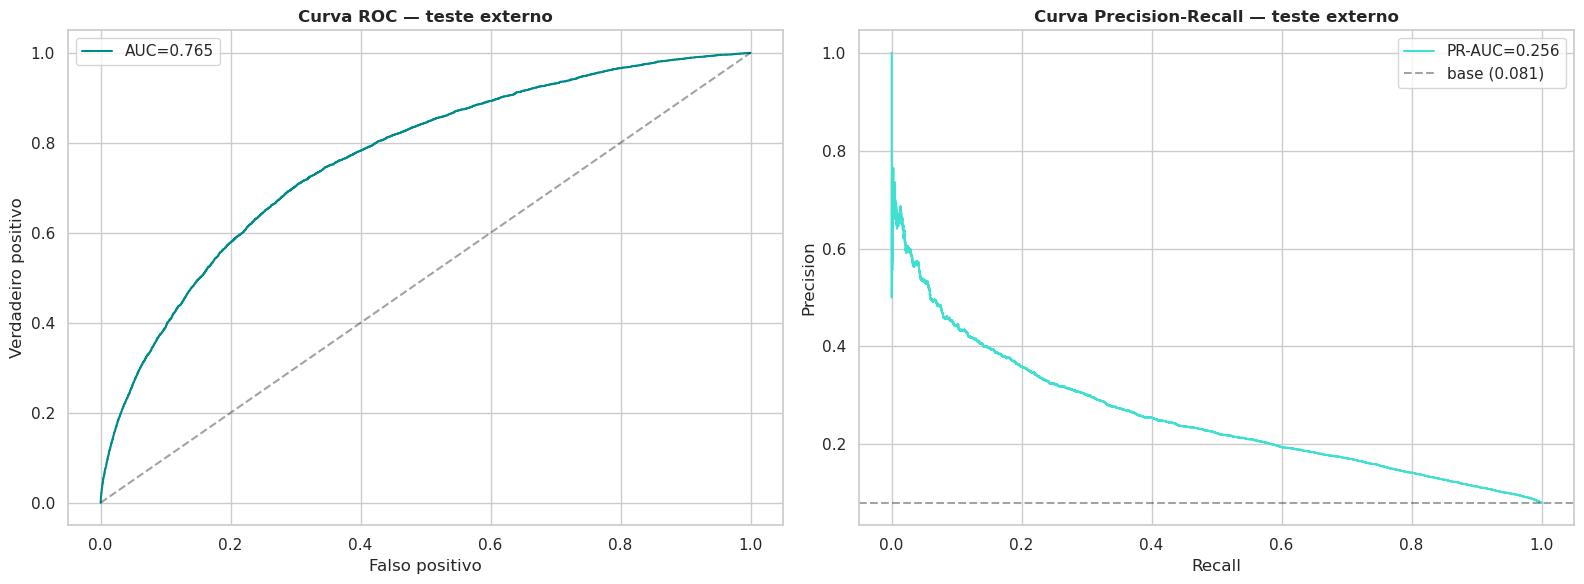

In [4]:
# Curvas ROC e Precision-Recall
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fpr, tpr, _ = roc_curve(y_arr, proba_teste)
axes[0].plot(fpr, tpr, color="darkcyan", label=f"AUC={roc_auc_score(y_arr, proba_teste):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_title("Curva ROC — teste externo", fontweight="bold")
axes[0].set_xlabel("Falso positivo"); axes[0].set_ylabel("Verdadeiro positivo"); axes[0].legend()
prec, rec, _ = precision_recall_curve(y_arr, proba_teste)
axes[1].plot(rec, prec, color="turquoise", label=f"PR-AUC={average_precision_score(y_arr, proba_teste):.3f}")
axes[1].axhline(y_arr.mean(), color="k", linestyle="--", alpha=0.4, label=f"base ({y_arr.mean():.3f})")
axes[1].set_title("Curva Precision-Recall — teste externo", fontweight="bold")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend()
plt.tight_layout(); plt.show()


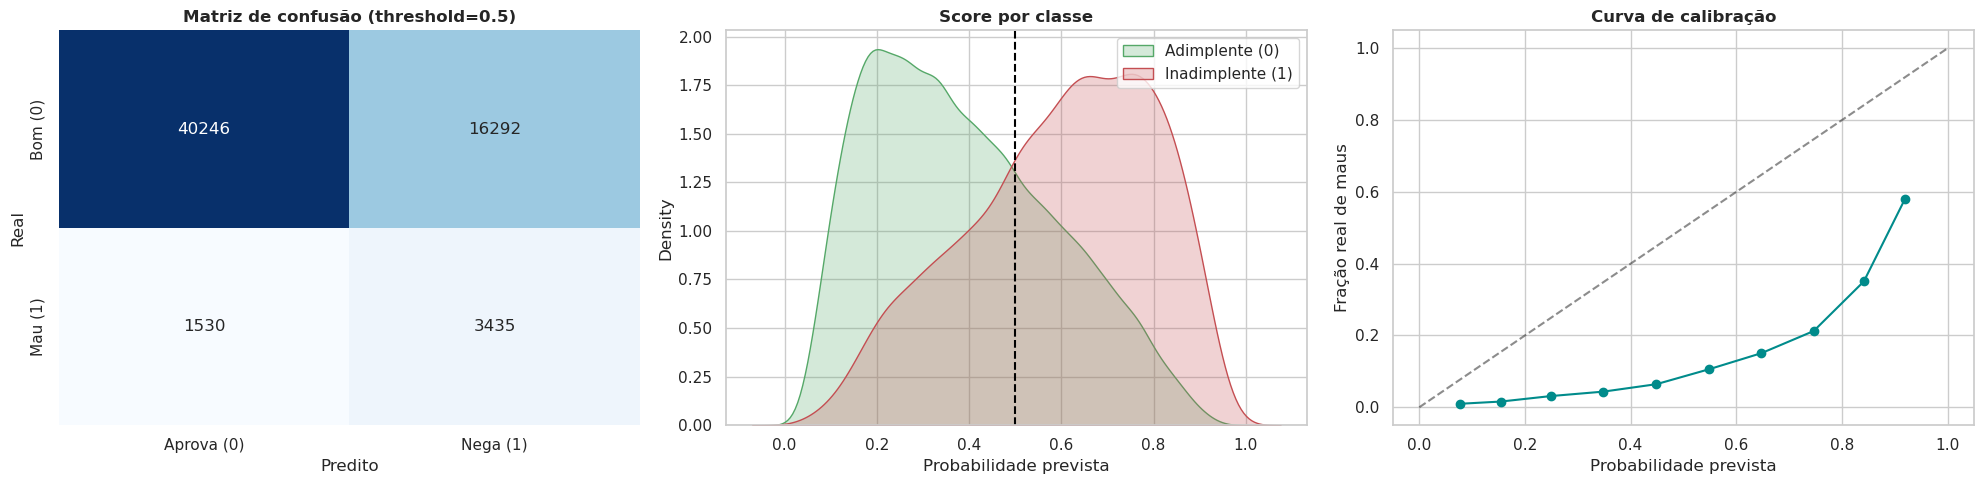

                  precision    recall  f1-score   support

  Adimplente (0)     0.9634    0.7118    0.8187     56538
Inadimplente (1)     0.1741    0.6918    0.2782      4965

        accuracy                         0.7102     61503
       macro avg     0.5688    0.7018    0.5485     61503
    weighted avg     0.8997    0.7102    0.7751     61503



In [5]:
# Matriz de confusão + distribuição do score + calibração (threshold do config)
pred = (proba_teste >= THRESHOLD).astype(int)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

sns.heatmap(confusion_matrix(y_arr, pred), annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Aprova (0)", "Nega (1)"], yticklabels=["Bom (0)", "Mau (1)"])
axes[0].set_title(f"Matriz de confusão (threshold={THRESHOLD})", fontweight="bold")
axes[0].set_xlabel("Predito"); axes[0].set_ylabel("Real")

sns.kdeplot(proba_teste[y_arr == 0], label="Adimplente (0)", color="g", fill=True, ax=axes[1])
sns.kdeplot(proba_teste[y_arr == 1], label="Inadimplente (1)", color="r", fill=True, ax=axes[1])
axes[1].axvline(THRESHOLD, color="black", linestyle="--"); axes[1].set_title("Score por classe", fontweight="bold")
axes[1].set_xlabel("Probabilidade prevista"); axes[1].legend()

frac_pos, mean_pred = calibration_curve(y_arr, proba_teste, n_bins=10)
axes[2].plot(mean_pred, frac_pos, "o-", color="darkcyan"); axes[2].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[2].set_title("Curva de calibração", fontweight="bold")
axes[2].set_xlabel("Probabilidade prevista"); axes[2].set_ylabel("Fração real de maus")
plt.tight_layout(); plt.show()

print(classification_report(y_arr, pred, target_names=["Adimplente (0)", "Inadimplente (1)"], digits=4))


> ### 📊 Análise — desempenho no teste externo
>
> **Por que fazer:** medir o desempenho **real** no holdout (dados nunca vistos), com as métricas próprias
> de risco de crédito, e checar generalização e calibração.
>
> **O que observar:** o **AUC ≈ 0,758 · Gini ≈ 0,515 · KS ≈ 0,39** deve bater com o `metrics.json` gerado
> pelo `train.py` (mesma seed e mesmo split — reprodutibilidade). O **AUC de teste ≈ AUC de validação
> cruzada (0,755)** confirma que **não há overfitting escondido**. O **KS ≈ 0,39** está na faixa de
> scorecards de mercado (0,30–0,50). A calibração fica **abaixo da diagonal** (score inflado pelo
> `class_weight="balanced"`, Brier alto): o *ranking* de risco vale, mas para probabilidade calibrada
> usaríamos `CalibratedClassifierCV`.
>
> **Conclusão:** o modelo **generaliza** (teste ≈ validação) e tem KS de mercado — confiável para virar
> política de crédito.


### **4. Leitura de negócio — decis e política de corte**

Métrica técnica vira decisão via ponto de corte. A tabela de **decis** mostra onde os maus se concentram
(poder de ordenação); a **varredura de thresholds** dá o cardápio de operação (quanto negar × quanto de
mau capturar × inadimplência residual dos aprovados).


In [6]:
# Tabela de decis (10 = maior risco)
df_sc = pd.DataFrame({"y": y_arr, "score": proba_teste})
df_sc["decil"] = pd.qcut(df_sc["score"], 10, labels=False, duplicates="drop") + 1
tab = df_sc.groupby("decil").agg(clientes=("y", "size"), maus=("y", "sum"), score_medio=("score", "mean"))
tab["taxa_default_%"] = (tab["maus"] / tab["clientes"] * 100).round(2)
tab["lift"] = (tab["maus"] / tab["clientes"] / df_sc["y"].mean()).round(2)
tab = tab.sort_index(ascending=False)
tab["captura_acum_%"] = (tab["maus"].cumsum() / tab["maus"].sum() * 100).round(1)
print(f"Taxa média de default no teste: {df_sc['y'].mean()*100:.2f}%")
tab


Taxa média de default no teste: 8.07%


,clientes,maus,score_medio,taxa_default_%,lift,captura_acum_%
decil,,,,,,
10,6151,1703,0.7883,27.6900,3.4300,34.3000
9,6150,938,0.6526,15.2500,1.8900,53.2000
8,6150,661,0.5585,10.7500,1.3300,66.5000
7,6150,479,0.4788,7.7900,0.9600,76.2000
6,6150,333,0.4093,5.4100,0.6700,82.9000
5,6151,270,0.3458,4.3900,0.5400,88.3000
4,6150,214,0.2876,3.4800,0.4300,92.6000
3,6150,180,0.2317,2.9300,0.3600,96.2000
2,6150,118,0.1768,1.9200,0.2400,98.6000


In [7]:
# Varredura de thresholds (política: negar se score >= t)
linhas = []
for t in [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]:
    neg = proba_teste >= t
    linhas.append({"threshold": t, "%_negados": neg.mean()*100,
                   "%_maus_capturados": (y_arr[neg] == 1).sum()/max((y_arr == 1).sum(), 1)*100,
                   "default_aprovados_%": y_arr[~neg].mean()*100 if (~neg).any() else np.nan})
pd.DataFrame(linhas).round(2)


,threshold,%_negados,%_maus_capturados,default_aprovados_%
0,0.3000,62.8600,89.5100,2.2800
1,0.4000,46.3700,80.5800,2.9200
2,0.5000,32.0700,69.1800,3.6600
3,0.6000,20.2900,53.7200,4.6900
4,0.7000,10.6400,35.6700,5.8100
5,0.8000,3.7500,17.5400,6.9200


> ### 📊 Análise — leitura de negócio (decis e política de corte)
>
> **Por que fazer:** métrica técnica só convence a banca quando vira **decisão e valor**. A tabela de decis
> mostra o poder de ordenação; a varredura de threshold mostra o cardápio de operação.
>
> **O que observar:** o **decil de maior risco** concentra várias vezes a inadimplência média (**lift** bem
> acima de 1) e os piores decis capturam a maior parte dos maus — evidência de ordenação. Na varredura,
> cortes mais rígidos (threshold maior) **negam mais pedidos**, **capturam mais maus** e **derrubam a
> inadimplência dos aprovados** abaixo da taxa-base.
>
> **Conclusão:** o modelo **ordena risco de forma acionável**. O ponto de corte é uma **decisão de
> negócio** (mais rígido = menos inadimplência, porém mais bons recusados); com o custo de um default e a
> margem por bom cliente, cada política vira um valor esperado em R$ — o argumento central do pitch.


### **5. Threshold ótimo — política por valor esperado**

O ponto de corte é uma **decisão de negócio**: em vez de fixá-lo por métrica estatística, escolhemos o `t`
que **maximiza o lucro esperado em R$**, ponderando cada cliente pelo valor do empréstimo (`amt_credit`).
Comparamos com o baseline estatístico de **Youden/KS** (que ignora valor) e com o `decision_threshold` do
config.

Política: **aprova se `score < t`**. Premissas de negócio (ajustáveis):
- `MARGEM` — margem líquida sobre o crédito de um bom pagador;
- `LGD` (*loss given default*) — fração do principal perdida num mau pagador.

> As premissas entram porque a base não traz a taxa de juros da aplicação atual; por isso fazemos também
> uma **análise de sensibilidade**. Como usamos **desfechos observados** no holdout, a análise **não depende
> de probabilidade calibrada**.


In [8]:
# Baseline estatístico (sem valor): threshold de Youden = ponto de KS máximo
fpr, tpr, thr = roc_curve(y_arr, proba_teste)
t_youden = float(thr[np.argmax(tpr - fpr)])
print(f"Threshold Youden/KS (baseline estatístico): {t_youden:.3f} | KS={np.max(tpr - fpr):.3f}")


Threshold Youden/KS (baseline estatístico): 0.488 | KS=0.405


In [9]:
# Varredura ponderada por valor: escolhe o t que maximiza o lucro esperado (R$)
amt  = X_teste["amt_credit"].fillna(X_teste["amt_credit"].median()).to_numpy(dtype=float)
maus = (y_arr == 1)
bons = (y_arr == 0)

MARGEM = 0.3   # margem líquida sobre o crédito de um bom pagador (premissa)
LGD    = 0.8   # loss given default: fração do principal perdida num mau pagador (premissa)

grid = np.round(np.linspace(0.05, 0.95, 181), 3)
linhas = []
for t in grid:
    aprov = proba_teste < t                       # aprova se score < t
    receita = MARGEM * amt[aprov & bons].sum()    # ganho com bons aprovados
    perda   = LGD    * amt[aprov & maus].sum()    # perda com maus aprovados
    linhas.append({"threshold": t, "%_aprovados": aprov.mean()*100,
                   "maus_aprovados": int((aprov & maus).sum()),
                   "R$_perda": perda, "R$_receita": receita,
                   "R$_lucro_esperado": receita - perda})
tab_lucro = pd.DataFrame(linhas)
t_otimo = float(tab_lucro.loc[tab_lucro["R$_lucro_esperado"].idxmax(), "threshold"])
print(f"Threshold ótimo (máximo lucro esperado): {t_otimo:.3f}")
print(f"Threshold do config (decision_threshold): {THRESHOLD}")
tab_show = tab_lucro.sort_values("R$_lucro_esperado", ascending=False).head(8).copy()
for _c in ["R$_perda", "R$_receita", "R$_lucro_esperado"]:
    tab_show[_c] = tab_show[_c].round(0)
tab_show


Threshold ótimo (máximo lucro esperado): 0.805
Threshold do config (decision_threshold): 0.5


,threshold,%_aprovados,maus_aprovados,R$_perda,R$_receita,R$_lucro_esperado
151,0.8050,96.4717,4132,1885542210.0000,9995972608.0000,8110430398.0000
149,0.7950,95.9693,4044,1849844293.0000,9959665173.0000,8109820880.0000
152,0.8100,96.7124,4176,1903920656.0000,10013016654.0000,8109095997.0000
150,0.8000,96.2522,4094,1870773120.0000,9978938898.0000,8108165778.0000
148,0.7900,95.6961,4001,1831728524.0000,9939176333.0000,8107447808.0000
153,0.8150,96.9351,4217,1921234723.0000,10027510434.0000,8106275711.0000
147,0.7850,95.4392,3961,1817033339.0000,9922629846.0000,8105596507.0000
146,0.7800,95.1515,3918,1799397256.0000,9902223130.0000,8102825874.0000


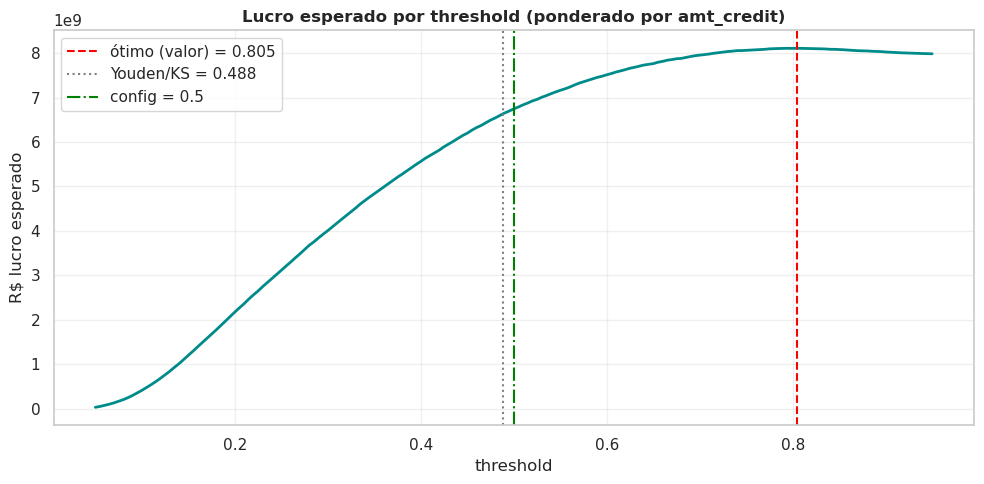

In [10]:
# Curva de lucro esperado x threshold, com os tres cortes candidatos
plt.figure(figsize=(10, 5))
plt.plot(tab_lucro["threshold"], tab_lucro["R$_lucro_esperado"], color="darkcyan", lw=2)
plt.axvline(t_otimo, color="red", ls="--", label=f"ótimo (valor) = {t_otimo:.3f}")
plt.axvline(t_youden, color="gray", ls=":", label=f"Youden/KS = {t_youden:.3f}")
plt.axvline(THRESHOLD, color="green", ls="-.", label=f"config = {THRESHOLD}")
plt.title("Lucro esperado por threshold (ponderado por amt_credit)", fontweight="bold")
plt.xlabel("threshold"); plt.ylabel("R$ lucro esperado")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [11]:
# Sensibilidade: o threshold ótimo é estável frente às premissas de margem e LGD?
margens = [0.15, 0.20, 0.25]
lgds    = [0.60, 0.75, 0.90]
sens = pd.DataFrame(index=[f"margem={m:.0%}" for m in margens],
                    columns=[f"LGD={l:.0%}" for l in lgds], dtype=float)
for m in margens:
    for l in lgds:
        lucro = np.array([m*amt[(proba_teste < t) & bons].sum()
                          - l*amt[(proba_teste < t) & maus].sum() for t in grid])
        sens.loc[f"margem={m:.0%}", f"LGD={l:.0%}"] = grid[int(np.argmax(lucro))]
print("Threshold ótimo por cenário (margem x LGD):")
sens


Threshold ótimo por cenário (margem x LGD):


,LGD=60%,LGD=75%,LGD=90%
margem=15%,0.7400,0.6950,0.6400
margem=20%,0.7950,0.7400,0.7300
margem=25%,0.8100,0.7950,0.7400


> ### 📊 Análise — threshold ótimo por valor esperado
>
> **Por que fazer:** o corte é uma decisão de negócio; otimizá-lo em **R$** (e não em métrica estatística)
> conecta o modelo direto ao resultado — critério RESULTS.
>
> **O que observar:** compare os três cortes na curva de lucro — **valor (ótimo)**, **Youden/KS** e o
> **config (0,5)**. Se o ótimo por valor for **mais suave** que o de Youden, é sinal de que os maus aprovados
> nessa faixa têm **exposição baixa** — a hipótese de que empréstimos pequenos toleram um corte mais leniente.
> A tabela de **sensibilidade** mostra se o `t_otimo` se mantém quando variamos margem e LGD: quanto mais
> estável, mais defensável a política.
>
> **Ressalva metodológica:** aqui o corte foi escolhido **no próprio holdout**, para ilustrar. Em produção,
> escolha o threshold num split de **validação** e reporte no teste, para não superestimar o ganho.


#### Validação — matriz de confusão, precisão, recall, F1, G-mean e MCC por threshold

Convenção (crédito): **classe positiva = 1 = inadimplente**; **predito positivo = "negar"** (score ≥ t).
Então, por threshold:

| célula | significado | |
|---|---|---|
| **TP** | mau **negado** | acerto (evitou default) |
| **FP** | bom **negado** | erro — perde receita de um bom cliente |
| **FN** | mau **aprovado** | erro **custoso** — vira default |
| **TN** | bom **aprovado** | acerto |

- **precisão** = TP/(TP+FP): entre os **negados**, quantos eram de fato maus.
- **recall** = TP/(TP+FN): entre os **maus**, quantos foram negados (= `%_maus_capturados`).
- **F1**: média harmônica de precisão e recall (simétrica — ignora TN).
- **G-mean** = √(recall · especificidade): equilibra a sensibilidade das **duas** classes — robusto a desbalanceamento.
- **MCC** (Matthews): correlação predito×real usando as **4 células**; só é alto se o modelo acerta as duas classes. É o resumo único mais robusto sob desbalanceamento.


In [12]:
def confusao_metrica(t):
    negar = proba_teste >= t                     # predito positivo = negar (inadimplente previsto)
    TP = int(((y_arr == 1) & negar).sum())       # mau negado  (acerto)
    FP = int(((y_arr == 0) & negar).sum())       # bom negado  (perde receita)
    FN = int(((y_arr == 1) & ~negar).sum())      # mau aprovado (default)
    TN = int(((y_arr == 0) & ~negar).sum())      # bom aprovado (acerto)
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0           # recall / TPR (sensibilidade)
    spec = TN / (TN + FP) if (TN + FP) else 0.0           # especificidade / TNR
    acc = (TP + TN ) / (TP + TN + FP + FN) if (TP + TN + FP + FN) else 0.0         # Acurácia
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    gmean = np.sqrt(rec * spec)                           # equilibra as sensibilidades das 2 classes
    den = np.sqrt(float(TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))   # MCC usa as 4 células
    mcc = (TP * TN - FP * FN) / den if den else 0.0
    relacao_FN_TN = FN / TN if TN else 0.0 
    return {"threshold": round(float(t), 3),
            "TN_bom_aprov": TN, "FP_bom_negado": FP, "FN_mau_aprov": FN, "TP_mau_negado": TP, "acuracia": round(acc,4),
            "precisao": round(prec, 4), 
            "recall": round(rec, 4), 
            "spec": round(spec, 4), 
            "f1": round(f1, 4),
            # "gmean": round(float(gmean), 4), 
            "mcc": round(mcc, 4)
            }

# Thresholds que maximizam cada critério estatístico (sobre a grade fina)
f1_grid  = np.array([confusao_metrica(t)["f1"]    for t in grid])
# gm_grid  = np.array([confusao_metrica(t)["gmean"] for t in grid])
# mcc_grid = np.array([confusao_metrica(t)["mcc"]   for t in grid])
t_f1  = float(grid[int(np.argmax(f1_grid))])
# t_gm  = float(grid[int(np.argmax(gm_grid))])
# t_mcc = float(grid[int(np.argmax(mcc_grid))])
print(f"Threshold F1-ótimo    : {t_f1:.3f} (F1={f1_grid.max():.4f})")
# print(f"Threshold G-mean-ótimo: {t_gm:.3f} (G-mean={gm_grid.max():.4f})")
# print(f"Threshold MCC-ótimo   : {t_mcc:.3f} (MCC={mcc_grid.max():.4f})")

# Tabela: grade original + cortes de referência (config, Youden, F1, G-mean, MCC, valor)
refs = sorted(set([0.30, 0.40, 0.50, 0.52, 0.55, 0.58, 0.60, 0.70, 0.80,]))
                   # round(t_youden, 3), round(t_f1, 3), round(t_gm, 3),
                   # round(t_mcc, 3), round(t_otimo, 3)]))
tab_cm = pd.DataFrame([confusao_metrica(t) for t in refs])

# Deltas entre linhas: corte ATUAL menos o ANTERIOR (tabela ordenada por threshold crescente).
# Afrouxar o corte (t maior) aprova mais gente -> TN (bons aprovados) e FN (maus aprovados) sobem.
tab_cm["delta_TN"] = tab_cm["TN_bom_aprov"].diff()           # bons aprovados a mais que o corte anterior
tab_cm["delta_FN"] = tab_cm["FN_mau_aprov"].diff()           # maus aprovados a mais que o corte anterior
# maus EXTRAS por cada bom EXTRA ao afrouxar um degrau (razao marginal do trade-off)
tab_cm["delta_FN/TN"] = (tab_cm["delta_FN"] / tab_cm["delta_TN"]).round(4)
tab_cm["delta_TN/FN"] = (tab_cm["delta_TN"] / tab_cm["delta_FN"]).round(4)
tab_cm

Threshold F1-ótimo    : 0.635 (F1=0.3117)


,threshold,TN_bom_aprov,FP_bom_negado,FN_mau_aprov,TP_mau_negado,acuracia,precisao,recall,spec,f1,mcc,delta_TN,delta_FN,delta_FN/TN,delta_TN/FN
0,0.3000,22322,34216,521,4444,0.4352,0.1150,0.8951,0.3948,0.2037,0.1634,NaN,NaN,NaN,NaN
1,0.4000,32022,24516,964,4001,0.5857,0.1403,0.8058,0.5664,0.2390,0.2033,9700.0000,443.0000,0.0457,21.8962
2,0.5000,40246,16292,1530,3435,0.7102,0.1741,0.6918,0.7118,0.2782,0.2356,8224.0000,566.0000,0.0688,14.5300
3,0.5200,41640,14898,1678,3287,0.7305,0.1808,0.6620,0.7365,0.2840,0.2379,1394.0000,148.0000,0.1062,9.4189
4,0.5500,43664,12874,1907,3058,0.7597,0.1919,0.6159,0.7723,0.2927,0.2414,2024.0000,229.0000,0.1131,8.8384
5,0.5800,45551,10987,2130,2835,0.7867,0.2051,0.5710,0.8057,0.3018,0.2458,1887.0000,223.0000,0.1182,8.4619
6,0.6000,46723,9815,2298,2667,0.8031,0.2137,0.5372,0.8264,0.3057,0.2462,1172.0000,168.0000,0.1433,6.9762
7,0.7000,51768,4770,3194,1771,0.8705,0.2708,0.3567,0.9156,0.3078,0.2406,5045.0000,896.0000,0.1776,5.6306
8,0.8000,55104,1434,4094,871,0.9101,0.3779,0.1754,0.9746,0.2396,0.2152,3336.0000,900.0000,0.2698,3.7067


### Pontos de discussão:
- quanto que o banco vai ter de lucro líquido com as concessões de crédito? Diferença entre quanto lucro das operações pagas e das perdas das operações inadimplentes
- Avaliar proporção de novos bons pagadores e novos maus pagadores no caso de aumentar o threshold (`delta_FN_por_delta_TN`)
- Avaliar quantos bons pagadores são necessários para cobrir um mau pagador. Pode ser utilizado como parâmetro para a definição do threshold. Pois isso irá definir o ponto ótimo do lucro com as operações de crédito.
- O threshold para aprovação automática será de <0.5, análise humana entre 0.5 e 0.6 e negação para >0.6. Esses valores podem ser revistos de acordo com os pontos de discussão acima.


> ### 📊 Análise — validação por matriz de confusão
>
> **Por que fazer:** decompor cada threshold em TP/FP/FN/TN e comparar critérios de corte adequados a base
> **desbalanceada** — **F1**, **G-mean** e **MCC** — ao lado dos cortes de negócio.
>
> **O que se observa:** subir o threshold (mais rígido) **aumenta a precisão** e **derruba o recall**. Cada
> critério dá um corte diferente — **Youden/KS**, **F1**, **G-mean**, **MCC** e **valor esperado**. O **MCC**
> é o resumo único mais robusto sob desbalanceamento (usa as 4 células, só é alto se acerta as duas classes);
> o **G-mean** equilibra as sensibilidades das duas classes. Todos os estatísticos, porém, **ignoram custo**
> (tratam FP e FN de forma simétrica).
>
> **Por que o valor-ótimo é o mais leniente (0,805) — duas forças opostas:** *por unidade*, um **FN (mau
> aprovado → default)** custa mais que um **FP (bom negado → margem perdida)**, o que empurraria para um corte
> mais **rígido**. Mas os **bons superam os maus em ~11:1** (base de ~8% de default) e **cada bom aprovado
> gera margem**, o que empurra para aprovar **mais**. Nesta base a segunda força vence. Nenhum dos critérios
> estatísticos (F1/G-mean/MCC) enxerga frequência das classes nem magnitude em R$.
>
> **Conclusão:** F1/G-mean/MCC são bons para *diagnóstico* e para escolher um corte **quando não há custos**
> (aí prefira MCC ou G-mean ao F1). Tendo os valores (`amt_credit`, LGD, margem), a decisão de crédito deve
> seguir o **valor esperado**, com um **teto de risco/inadimplência** por cima.


### **6. Interpretabilidade — importância por permutação**

Queda de AUC ao embaralhar cada variável (agnóstica ao modelo). Mede **poder preditivo real**, ao
contrário da importância nativa (contagem de *splits*).


Permutation importance em 16s


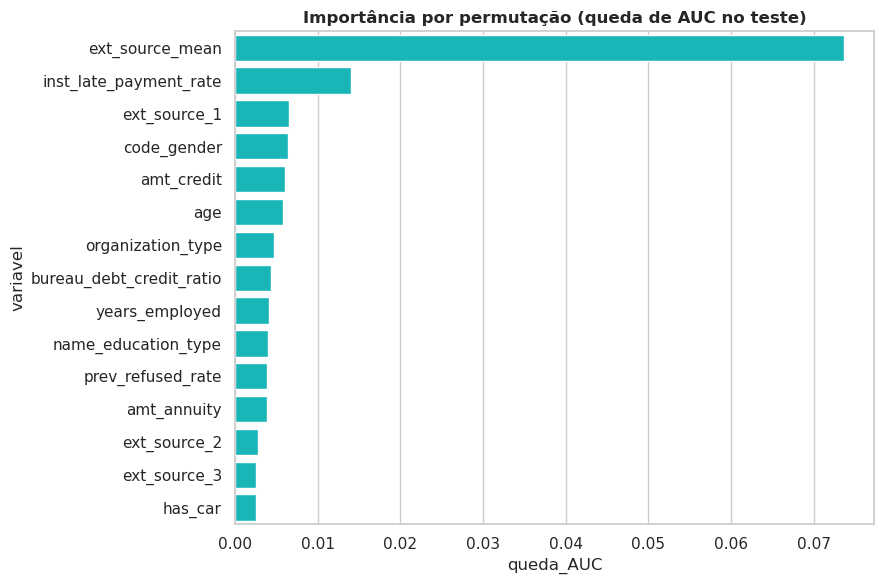

,variavel,queda_AUC
3,ext_source_mean,0.0736
35,inst_late_payment_rate,0.0140
0,ext_source_1,0.0066
41,code_gender,0.0064
18,amt_credit,0.0061
20,age,0.0058
38,organization_type,0.0048
32,bureau_debt_credit_ratio,0.0043
21,years_employed,0.0041
40,name_education_type,0.0039


In [13]:
amostra = X_teste.sample(n=min(15000, len(X_teste)), random_state=SEED)
y_amostra = y_teste.loc[amostra.index]
t0 = time.time()
perm = permutation_importance(modelo, amostra, y_amostra, scoring="roc_auc",
                              n_repeats=5, random_state=SEED, n_jobs=-1)
print(f"Permutation importance em {time.time()-t0:.0f}s")
imp_perm = (pd.DataFrame({"variavel": amostra.columns, "queda_AUC": perm.importances_mean})
            .sort_values("queda_AUC", ascending=False).head(15))
plt.figure(figsize=(9, 6))
sns.barplot(data=imp_perm, x="queda_AUC", y="variavel", color="darkturquoise")
plt.title("Importância por permutação (queda de AUC no teste)", fontweight="bold")
plt.tight_layout(); plt.show()
imp_perm.round(4)


### **7. Interpretabilidade — valores SHAP**

Efeito e direção de cada variável. Como o modelo usa **categóricas nativas**, o `TreeExplainer` do LightGBM
lida com elas diretamente; para o color-coding do beeswarm, as categorias viram códigos numéricos.


LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


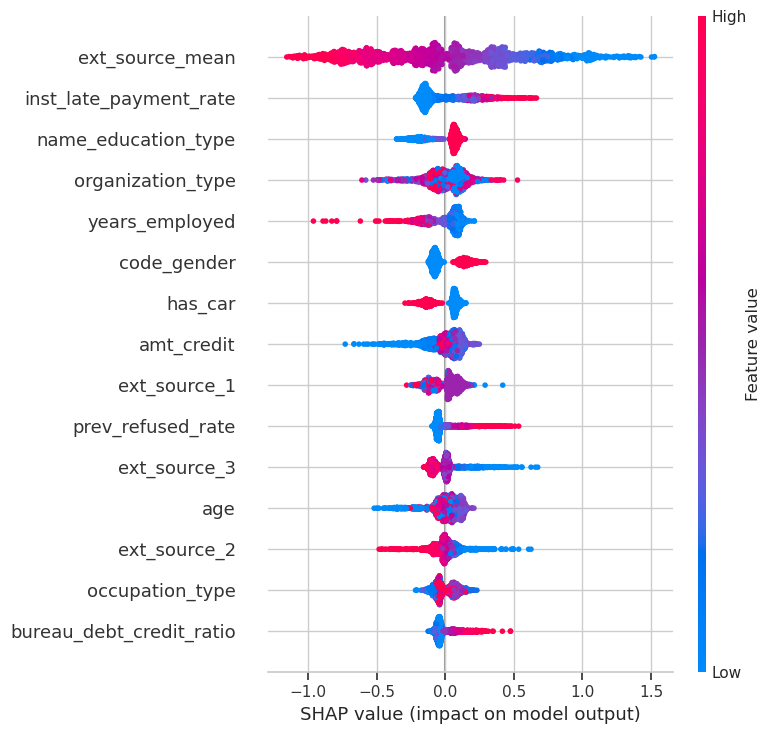

In [14]:
X_shap = X_teste.sample(n=min(2000, len(X_teste)), random_state=SEED)
try:
    explainer = shap.TreeExplainer(modelo)
    sv = explainer.shap_values(X_shap)
    if isinstance(sv, list):          # [classe_0, classe_1] em versões antigas
        sv = sv[1]
    # matriz numérica só para colorir o beeswarm (categóricas -> códigos)
    X_disp = X_shap.copy()
    for c in X_disp.select_dtypes(include="category").columns:
        X_disp[c] = X_disp[c].cat.codes
    shap.summary_plot(sv, X_disp, max_display=15, show=True)
except Exception as e:
    print("SHAP falhou:", str(e)[:200])

> ### 📊 Análise — interpretabilidade
>
> **Por que fazer:** abrir a "caixa" do modelo aumenta a **confiança** e atende à governança. A
> **permutação** mede o impacto real de cada variável na AUC; o **SHAP** mostra efeito e direção.
>
> **O que observar:** os **`ext_source_*`** (score externo de crédito, resumidos em `ext_source_mean`)
> tendem a **dominar** a importância — coerente com o alto IV encontrado na EDA. Variáveis como `age`,
> `years_employed` e o histórico de pagamentos (`inst_late_payment_rate`) aparecem em seguida. A permutação
> é a medida de **poder preditivo** (a contagem nativa de *splits* pode ordenar diferente). Se `code_gender`
> aparecer entre as relevantes, isso **motiva a análise de fairness** a seguir.
>
> **Conclusão:** a coerência **EDA → IV → modelo** é um forte argumento de confiabilidade, e nenhuma
> variável "sem sentido de negócio" no topo → sem sinal de vazamento.


### **8. Governança e fairness** *(critério RESULTS do projeto)*

A EDA sinalizou `code_gender` como atributo sensível. Verificamos **desempenho e política de corte por
subgrupo** para diagnosticar viés.


In [15]:
df_fair = X_teste[["code_gender"]].copy()
df_fair["y"] = y_arr
df_fair["score"] = proba_teste
df_fair["negado"] = (df_fair["score"] >= THRESHOLD).astype(int)
linhas = []
for g, sub in df_fair.groupby("code_gender", observed=True):
    l = {"grupo": g, "clientes": len(sub),
         "default_real_%": sub["y"].mean()*100, "%_negados": sub["negado"].mean()*100}
    if sub["y"].nunique() == 2:
        l["AUC_grupo"] = roc_auc_score(sub["y"], sub["score"])
        maus = sub[sub["y"] == 1]
        l["recall_%"] = maus["negado"].mean()*100 if len(maus) else np.nan
    linhas.append(l)
pd.DataFrame(linhas).round(3)


,grupo,clientes,default_real_%,%_negados,AUC_grupo,recall_%
0,F,40218,6.8750,26.3170,0.7630,63.2190
1,M,21284,10.3360,42.9520,0.7530,76.6820
2,Unknown,1,0.0000,100.0000,NaN,NaN


> ### 📊 Análise — governança e fairness
>
> **Por que fazer:** o critério **RESULTS** pede diagnóstico de viés e conformidade; como o modelo pode
> usar o gênero, verificamos o impacto por subgrupo.
>
> **O que observar:** se o **AUC for parecido entre os grupos**, não há disparidade de **desempenho** (o
> modelo ordena bem para ambos). Uma **taxa de negados diferente** entre grupos costuma **acompanhar o
> default real** de cada um — ou seja, o modelo **reflete o dado**, não inventa o viés. Ainda assim, uma
> disparidade de **decisão** deve ser **documentada e monitorada**.
>
> **Conclusão / mitigação:** treinar uma versão **sem `code_gender`** e medir a perda de AUC — se for
> marginal, remover a variável é defensável regulatoriamente.


**Métricas de monitoramento em produção** (rastreabilidade / conformidade):

| Dimensão | Métrica | Alerta sugerido |
|---|---|---|
| Performance | AUC / KS por safra | queda > 10% vs. baseline do teste |
| Estabilidade dos dados | **PSI** do score e das top features | PSI > 0,25 = mudança de população |
| Decisão | taxa de aprovação e default dos aprovados/mês | desvio da meta da política |
| Calibração | Brier / curva de calibração por safra | drift sistemático do score |
| Fairness | AUC e % negados por subgrupo | divergência crescente entre grupos |


### **9. Rastreabilidade — conferência com o artefato salvo**

Carregamos o artefato produzido pelo `train.py` e conferimos que as métricas recomputadas aqui batem com
as salvas no `metrics.json` — evidência de **reprodutibilidade** (mesmo modelo, mesma seed, mesmo split).


In [16]:
import pickle

artifact_path = NB_DIR.parent / config["metadata"]["artifact"]  # .../Model/artifacts/lightgbm_abt.pkl
if artifact_path.exists():
    with open(artifact_path, "rb") as f:
        artifact = pickle.load(f)
    print("Artefato:", artifact_path.name,
          "| treinado em:", artifact.get("trained_at_utc"),
          "| config:", artifact.get("config_version"))
    print("Métricas salvas no artefato :", artifact.get("metrics"))
else:
    print("Artefato ainda não gerado. Rode antes: python Model/train.py")
print("Métricas recomputadas (holdout):", credit_metrics(y_arr, proba_teste))


Artefato: lightgbm_abt.pkl | treinado em: 2026-07-10T21:37:37+00:00 | config: 1.0.0
Métricas salvas no artefato : {'roc_auc': 0.765, 'gini': 0.53, 'ks': 0.4051, 'average_precision': 0.2563, 'brier': 0.1909}
Métricas recomputadas (holdout): {'roc_auc': 0.765, 'gini': 0.53, 'ks': 0.4051, 'average_precision': 0.2563, 'brier': 0.1909}


### **10. Conclusão**

- O **modelo desenvolvido** (LightGBM regularizado, categóricas nativas) foi avaliado no **holdout honesto**:
  **generaliza** (teste ≈ validação), com **KS de mercado** e ordenação de risco acionável (decis/lift).
- A **interpretabilidade** (permutação + SHAP) mostra dependência coerente com o negócio (score externo,
  idade, histórico de pagamento) — sem sinal de vazamento.
- A **governança/fairness** documenta o comportamento por subgrupo e o **plano de monitoramento** (AUC/KS,
  PSI, calibração, fairness) fecha o critério RESULTS.
- A **seleção de modelos** que justifica esta escolha está em **`validacao_modelos.ipynb`**; o **uso em nova
  base** (Etapa 10) está no **`predict.py`** e no app da etapa individual.
